In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import gdown
import re
import os
import pandas as pd
import seaborn as sns
import scvi
import gc
import scipy as sp
import matplotlib as mpl
from cell2location.utils.filtering import filter_genes

def colour_tables(feature_series):
    features = list(set(feature_series))
    hex_features = []
    for i in range(len(features)):
        r = np.random.randint(0,200)
        g = np.random.randint(0,200)
        b = np.random.randint(0,200)
        colour = '#{:02x}{:02x}{:02x}'.format(r, g, b)
        hex_features.append(colour)
    return hex_features

In [ ]:
adata_tme = sc.read_h5ad('../data/adata/GBM_LEAP_TME_only.h5ad')
#adata.raw = adata

# Integration and clustering

In [ ]:
adata_tme.raw = adata_tme.copy()
adata_tme.layers['counts'] = adata_tme.X.copy()

# i.e. scanpy/seurat methods
sc.pp.normalize_total(adata_tme, target_sum=1e4)
sc.pp.log1p(adata_tme)

sc.pp.highly_variable_genes(adata_tme, 
                            min_mean=0.0075, 
                            max_mean=4, 
                            min_disp=0.1,
                            batch_key="donor_id"
)
selected = adata_tme.var['highly_variable']
adata_tme = adata_tme[:, selected].copy()

# check the UMAP without phase as a covariate
scvi.model.SCVI.setup_anndata(
    adata_tme,
    layer="counts",
    batch_key = "sample",
    categorical_covariate_keys=["date", "donor_id", "site_id"]
)

model = scvi.model.SCVI(adata_tme,
                       n_hidden = 1024,
                       n_layers = 2,
                       n_latent = 50,
                       gene_likelihood = 'nb',
                       dispersion = 'gene-batch',
                       use_observed_lib_size = True)
model.train(train_size=0.99, max_epochs=300, batch_size = 1024) #max_epochs=200

latent = model.get_latent_representation()
adata_tme.obsm["X_scVI"] = latent

# use scVI latent space for UMAP generation
sc.pp.neighbors(adata_tme, use_rep="X_scVI")
sc.tl.leiden(adata_tme, key_added="leiden_scVI_tme")

sc.tl.umap(adata_tme, min_dist=0.3)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 2/300:   0%|▏                                                          | 1/300 [00:28<2:19:41, 28.03s/it, loss=3.06e+03, v_num=1]

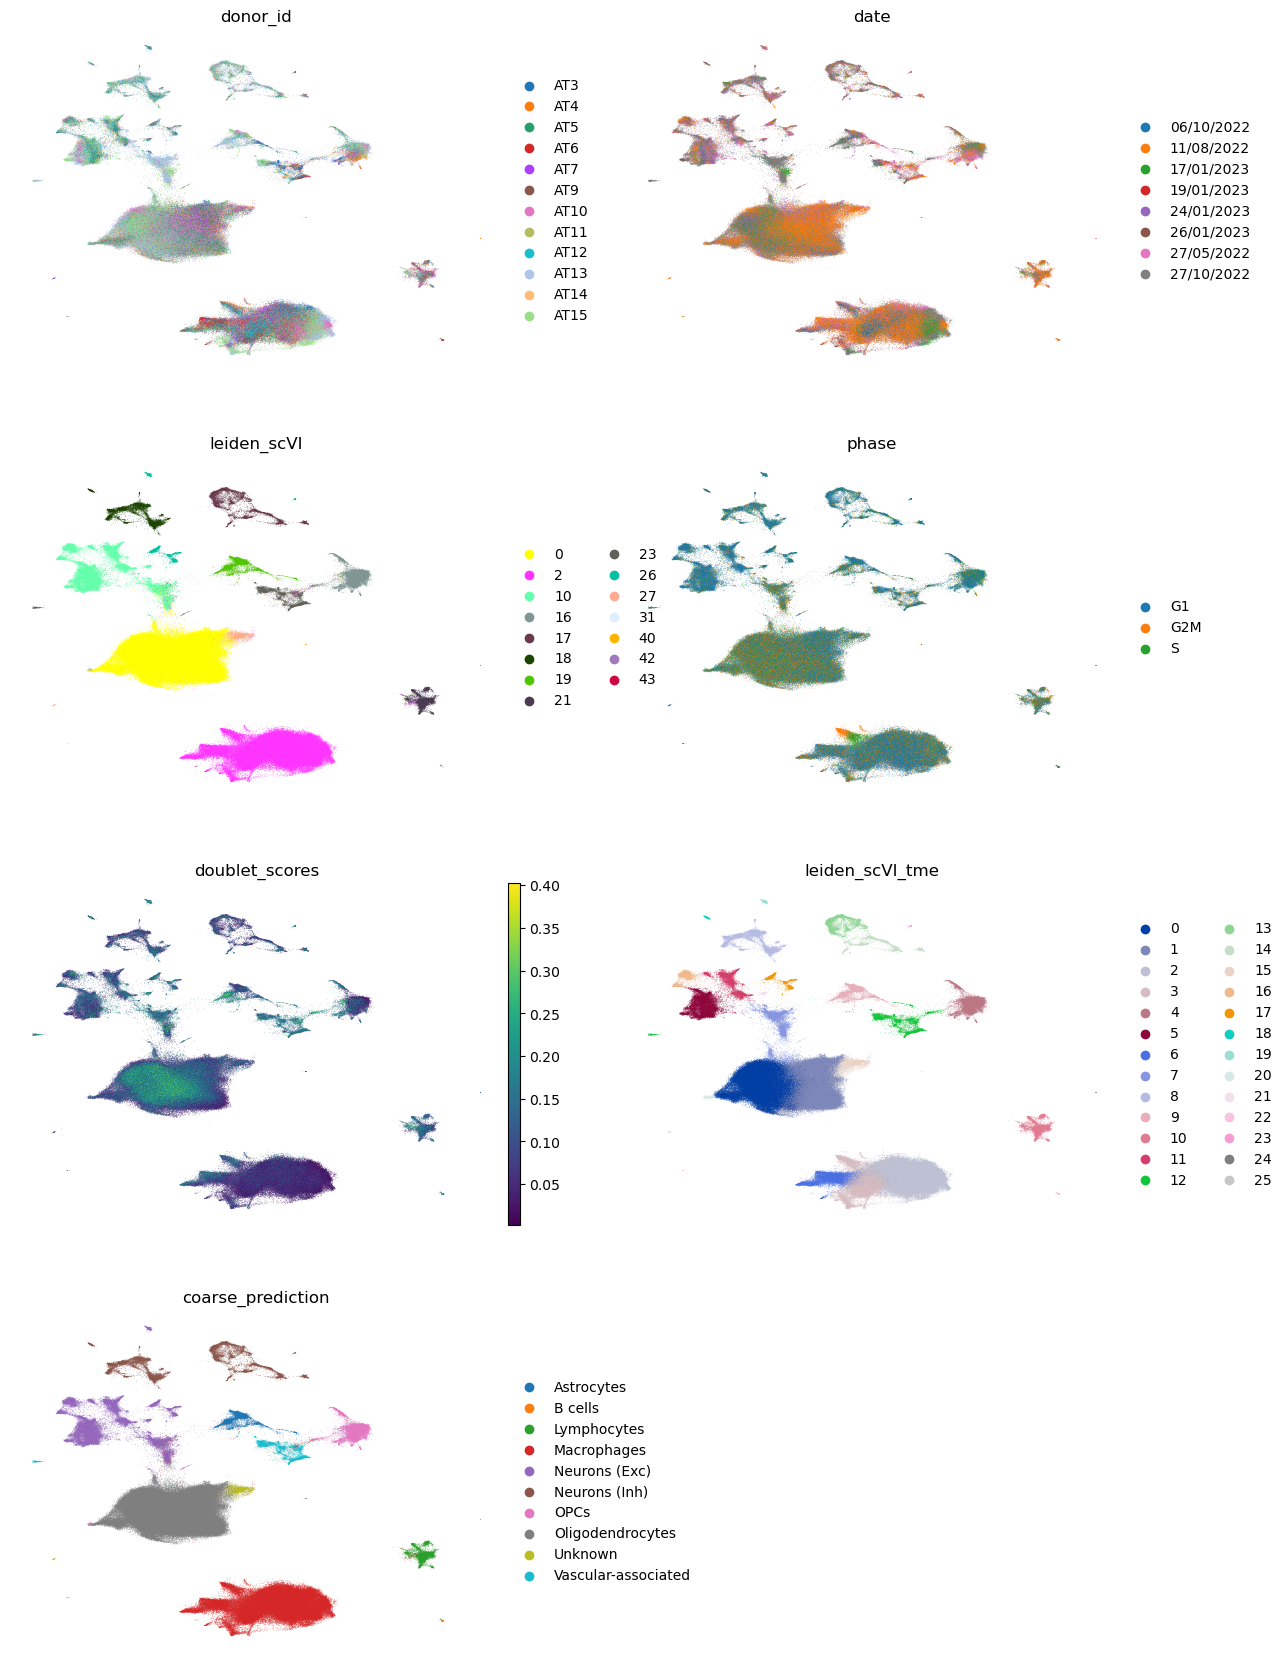

In [ ]:
# generate UMAP
sc.pl.umap(
    adata_tme,
    color=["donor_id", "date", "leiden_scVI", "phase", "doublet_scores", 
           "leiden_scVI_tme", "coarse_prediction"],
    ncols=2,
    size=0.5,
    frameon=False)

In [ ]:
adata_tme.write_h5ad('../data/adata/GBM_LEAP_TME.h5ad')

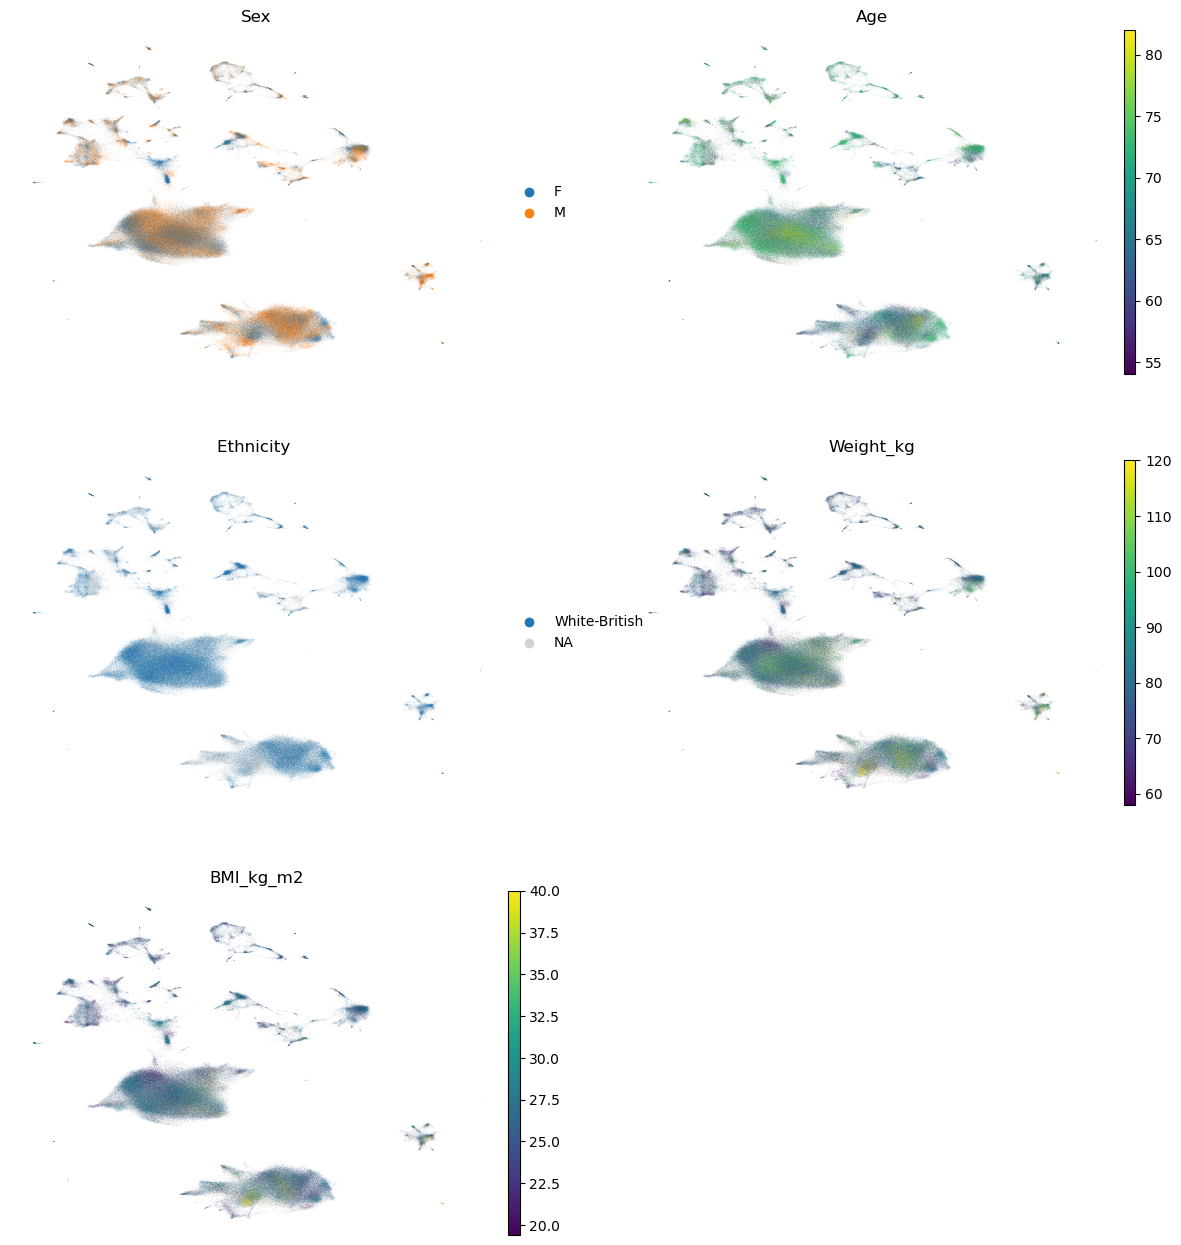

In [ ]:
# Check integration
# generate UMAP
sc.pl.umap(
    adata_tme,
    color=['Sex', 'Age', 'Ethnicity ', 'Weight_kg', 'BMI_kg_m2'],
    ncols=2,
    size=0.1,
    frameon=False)

# Annotation

In [ ]:
adata_tme = sc.read_h5ad('../data/adata/GBM_LEAP_TME.h5ad')

## Manual marker assessment

In [ ]:
marker_genes_plot = {
    'Neurons': ['RBFOX3', 'GRIN1', 'GRIN2A', 'RELN'],
    'Oligos': ['MOG', 'MAG', 'OPALIN'], #Oligos
    'OPCs': ['PDGFRA', 'SOX6', 'BCAN'], #OPCs
    'Astros': ['AQP4', 'GFAP', 'SLC17A8'], #Astros
    'Astro activated:':['P2RY14', 'MT3', 'VIM'],
    'Radial glia':['GFAP', 'SLC1A3', 'HES1', 'PAX6', 'SOX2'],
    'Micros': ['CX3CR1', 'AIF1', 'ITGAM', 'TREM2'], #Microglia
    'Endo': ['APOLD1', 'VWF'], #Endo
    'VLMC': ['COLEC12', 'CYP1B1', 'OGN', 'LUM', 'DCN'], #vascular and leptomeningeal cell
    'Peri': ['MUSTN1', 'DLC1', 'ANPEP'],
    'T cells': ['CD3G', 'CD8A'],
    'B cells': ['CD79A'],
    'SC':['PVT1', 'S100A1', 'S100B', 'GFAP', 'NGFR', 'SOX10', 'SOX2', 'GAP43']
}

marker_genes_eugene = {
    'Neurons': ['RBFOX3', 'DCX', 'MAP2', 'NCAM1', 'GRIN1', 'GRIN2A', 'FOS'], #Neurons
    'Neurons_G': ["SNAP25", "STMN2", "RBFOX3"],
    'Exc_G': ["SATB2","SLC17A7","SLC17A6", "CAMK2A", 'GRIA1', 'GRIA2'],
    'Inh_G': ["GAD1", "GAD2", "SLC32A1"],
    'Exc': ['SLC17A7', 'SLC17A6', 'LINC00507'], #Exc
    'Inh': ['GAD1', 'GAD2', 'ADARB2', 'LAMP5', 'PVALB', 'SST', 'HTR3A', 'VIP', 'SNCG', 'SV2C', 'CHODL'], #Inh
    'Layers': ['RELN', 'CUX1', 'CUX2', 'RORB', 'FEZF2', 'THEMIS'], #Layer specific
    'Oligos': ['PLP1', 'MBP', 'MOG', 'MAG', 'OPALIN', 'OLIG1', 'OLIG2', 'MYRF', 'FOXO1', 'FOXO4', 'CNP', 'GALC'], #Oligos
    'OPCs': ['PDGFRA', 'SOX6', 'SOX10', 'BCAN', 'MYT1', 'CSPG4'], #OPCs
    'SC':['PVT1', 'S100A1', 'S100B', 'GFAP', 'NGFR', 'SOX10', 'SOX2', 'GAP43'], 
    'Astros': ['AQP4', 'GFAP', 'POU3F2', 'FGFR3', 'EMX2', 'PAX6', 'SLC17A8', 'SLC1A2', 'SLC1A3', 'ALDH1L1', 'ETNPPL', 'MT1G'], #Astros
    'Astros A1': ['SERPING1', 'GBP2', 'AMIGO2', 'SRGN'], #PMC5404890
    'Astros A2': ['EMP1', 'SLC10A6', 'CD14', 'S100A10', 'CD109'], #PMC5404890
    'Astro Superficial Layers':['CHRDL1', 'APOE', 'EOGT'],
    'Astro Deep Layers':['ID1', 'ID3', 'PHGDH', 'CD44'],
    'Astro activated:':['P2RY14', 'MT3', 'VIM'],
    'Micros': ['TMEM119', 'CX3CR1', 'AIF1', 'ITGAM', 'CD33', 'TREM2'], #Microglia
    'M1 Micros': ['IL1B', 'TNF', 'STAT3', 'IL6', 'IL18'], #PMC4486922
    'M2 Micros': ['IL10', 'IL4', 'IL13', 'TGFB1', 'TGFB2', ], #PMC4486922
    'DAM Micros': ['TREM2', 'APOE', 'SPP1', 'TYROBP', 'CTSB'],
    'hypoxia':['HIF1A', 'HILPDA'],
    'Micro inflam': ['SRGN','CCL3','CCL4','IL1B'],
    'Phagocytosis':['CD163', 'P2RY12', 'LAMP1', 'LAMP2', 'HGSNAT', 'UNC13D', 'CD36', 'DNM2', 'CDC42', 'RAC1'], #CD163 and P2RY12 from 31316211 (microglia specific), rest are lysosome genes from PMC4387238 or phagocytosis GO
    'Endo': ['APOLD1', 'VWF', 'FLT1', 'CLDN5', 'VCAM1', 'EMCN', 
             'PLVAP'], #Endo
    'VLMC': ['PDGFRA', 'COLEC12', 'CYP1B1', 'OGN', 'LUM', 'DCN'], #vascular and leptomeningeal cell
    'Peri': ['MUSTN1', 'DLC1', 'ANPEP'],
    'Messenchymal':['VIM'],
    'T cells': ['CD3G', 'CD4', 'CD8A', 'CD8B', 'FAS'],
    'B cells': ['CD79A']
}

In [ ]:
# Load markers from 10X Xenium:
xenium = pd.read_csv('xenium_gene_list.tsv',sep = '\t')
xenium_brain_dict = {}
for i in sorted(set(xenium['Annotation'])):
    xenium_brain_dict[i] = xenium[xenium['Annotation']==i]['Gene'].tolist()
    

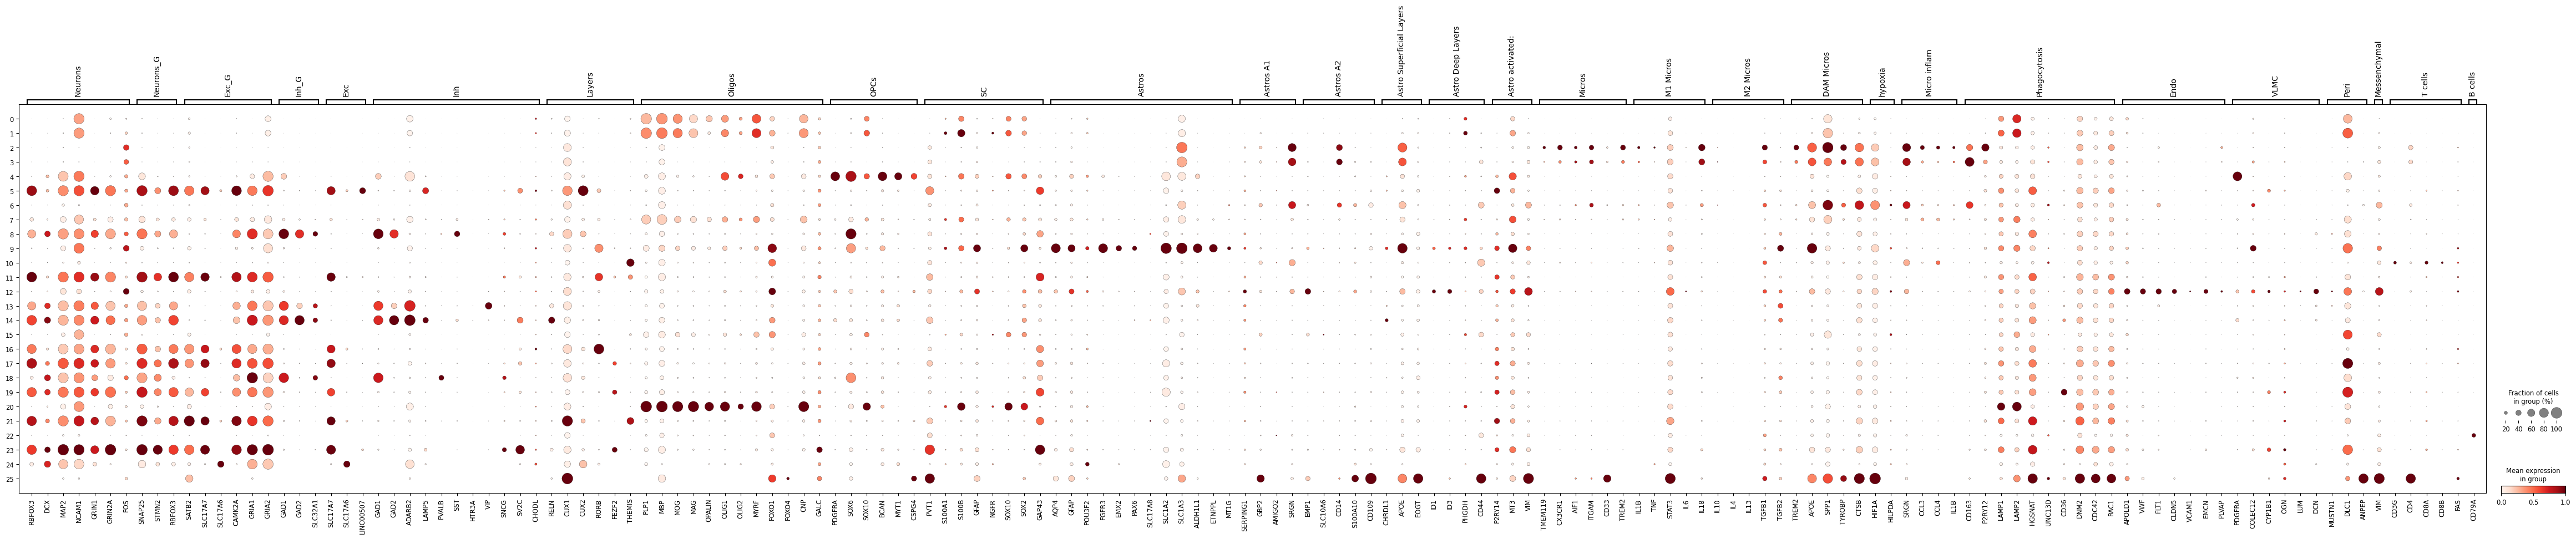

In [ ]:
sc.pl.dotplot(adata_tme, 
              marker_genes_eugene, 
              groupby='leiden_scVI_tme', 
              dendrogram=False, gene_symbols="SYMBOL", 
              standard_scale='var')

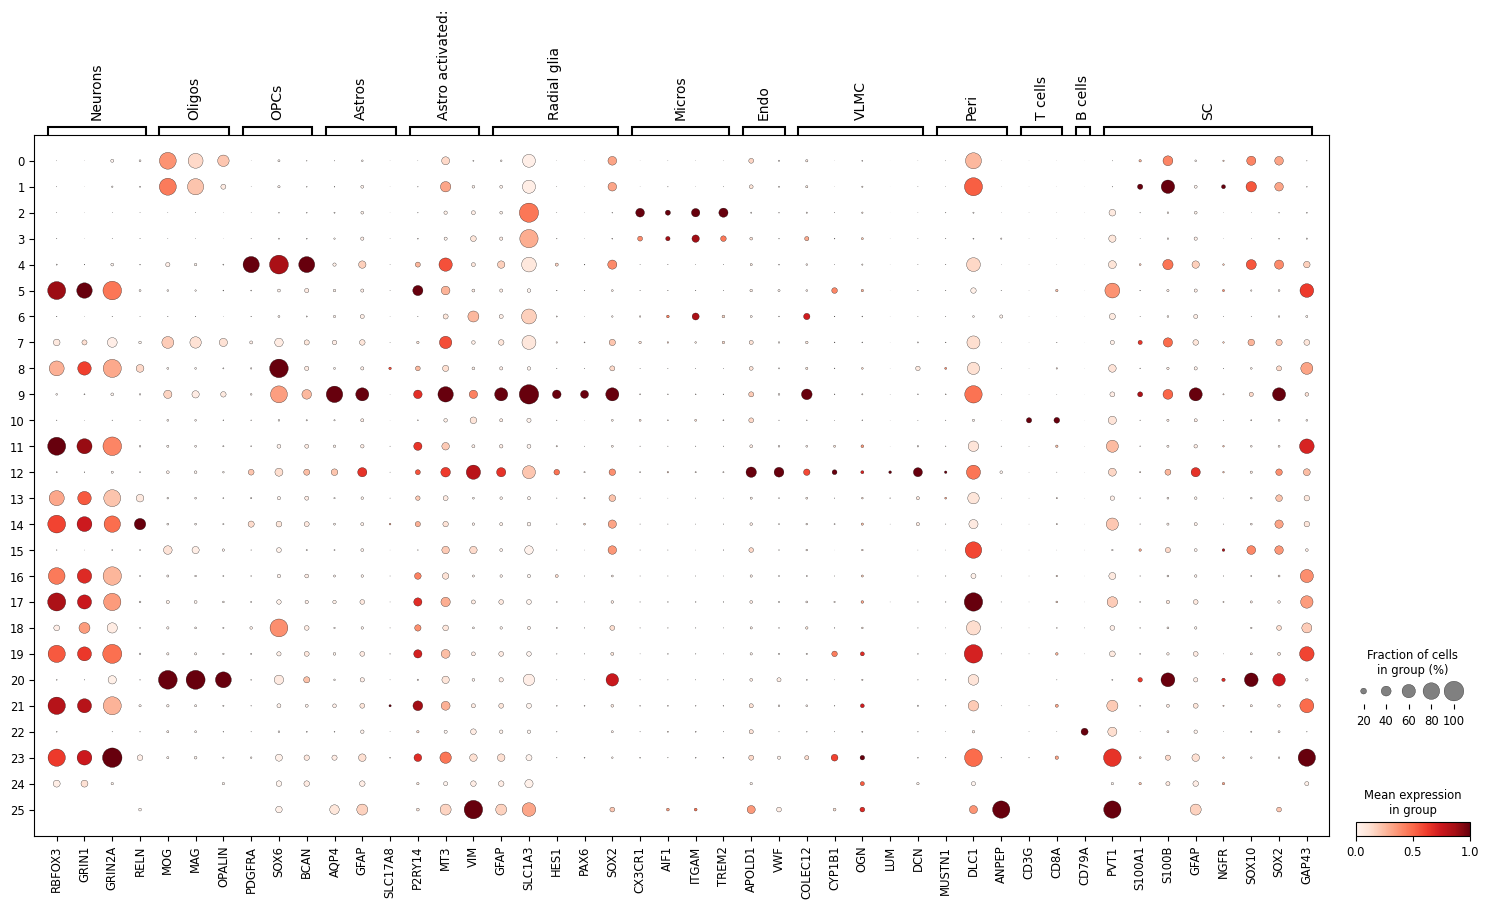

In [ ]:
sc.pl.dotplot(adata_tme, marker_genes_plot, groupby='leiden_scVI_tme', 
              dendrogram=False, gene_symbols="SYMBOL", standard_scale='var')

In [ ]:
leiden = 'leiden_scVI_tme'

## core annotation

# Neurons
exc_neurons = (adata_tme.obs[leiden].isin(['5', '11', '16', '17', '19', '21', '23']))
inh_neurons = (adata_tme.obs[leiden].isin(['8', '13', '14', '18']))

# macrophages
macrophages = (adata_tme.obs[leiden].isin(['2', '3', '6']))

# Vasculature, etc. 
endo_vlmc = adata_tme.obs[leiden]=='12'

# Oligodendrocytes
oligo = (adata_tme.obs[leiden].isin(['0', '1', '20']))

# Astrocytes
astros = (adata_tme.obs[leiden].isin(['9', '25']))

# OPCs
OPC = adata_tme.obs[leiden]=='4'

# T cells
t_cells = adata_tme.obs[leiden]=='10'

# B cells
b_cells = adata_tme.obs[leiden]=='22'

## Uncertain populations

# hypoxic oligos
hypo_oligos = adata_tme.obs[leiden].isin(['7', '15'])

In [ ]:
# Coarse annotation

# manually annotate
adata_tme.obs['coarse_TME'] = np.where(
    exc_neurons, 'Neurons (Exc)',
    np.where(inh_neurons, 'Neurons (Inh)',
             np.where(macrophages, 'Macrophages',
                    np.where(oligo, 'Oligodendrocytes',
                             np.where(astros, 'Astrocytes',
                                  np.where(b_cells, 'B cells',
                                        np.where(OPC, 'OPCs',
                                                 np.where(endo_vlmc, 'Vascular-associated',
                                                          np.where(t_cells, 'Lymphocytes',
                                                                   np.where(hypo_oligos, 
                                                                            'Hypoxic oligodendrocytes',
                                                                   'Unknown'))))))))))

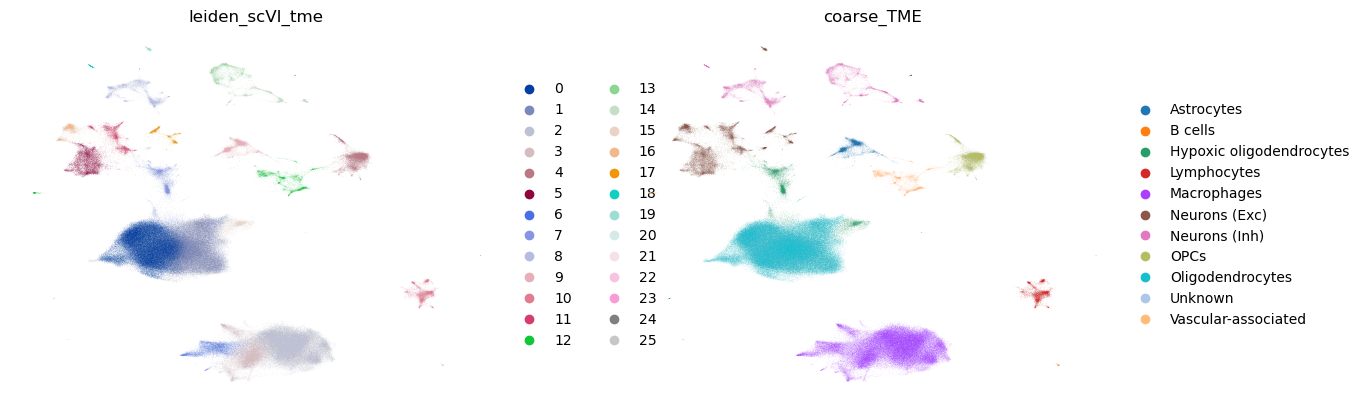

In [ ]:
# generate UMAP
sc.pl.umap(
    adata_tme,
    color=["leiden_scVI_tme", "coarse_TME"],
    ncols=2,
    size=0.1,
    frameon=False)

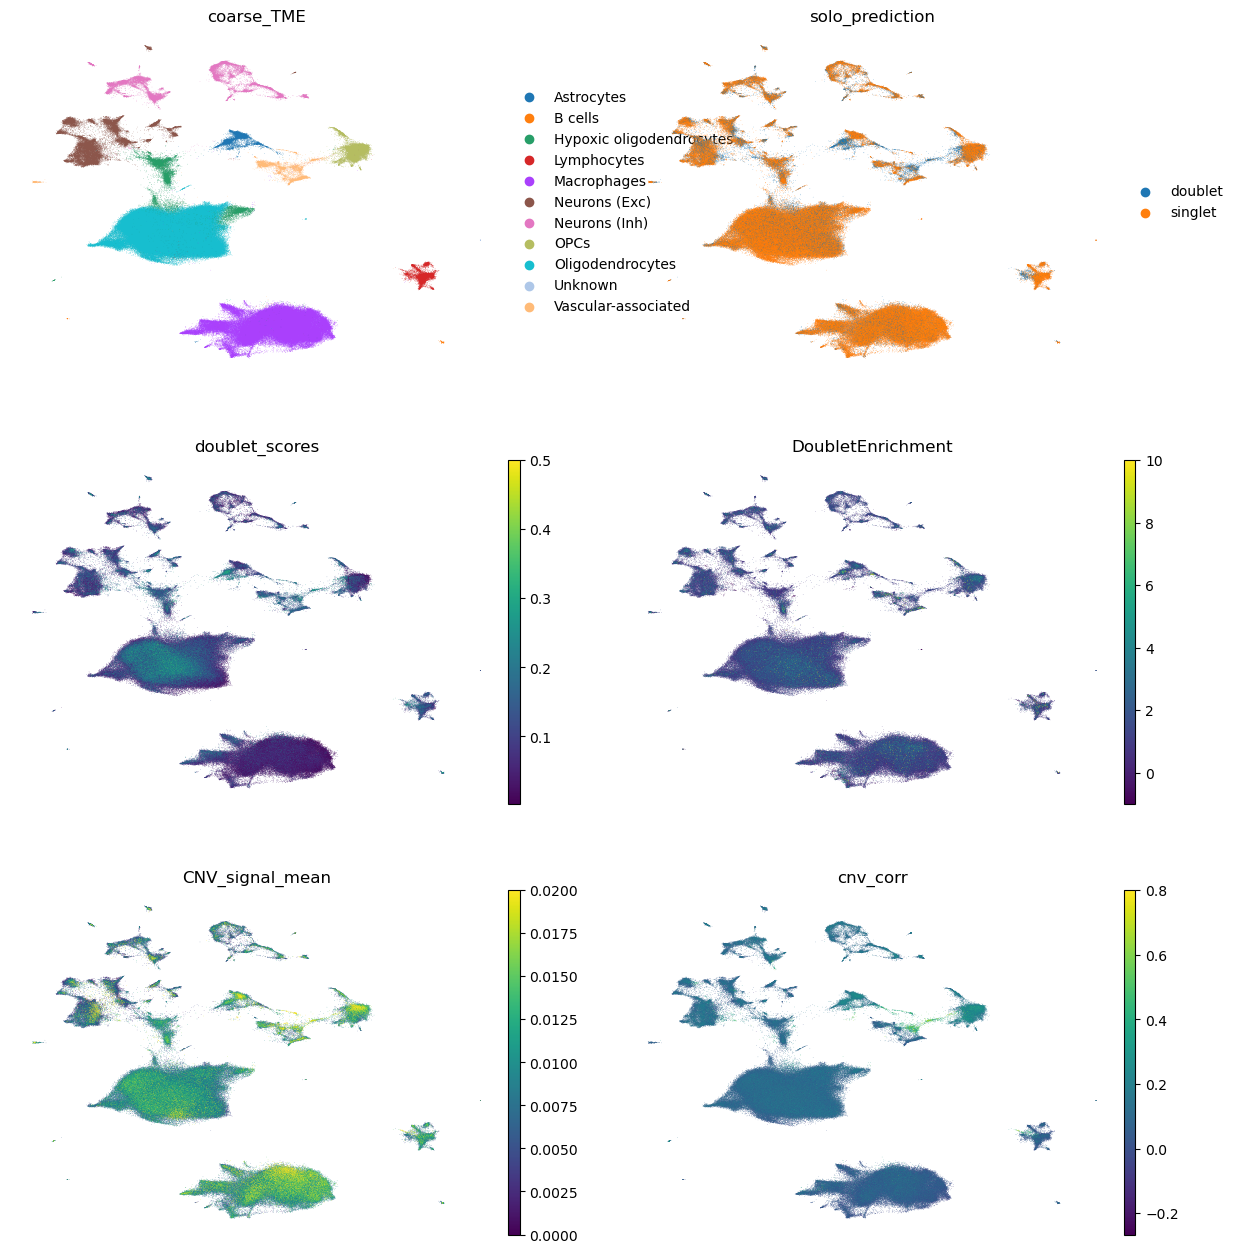

In [ ]:
# generate UMAP
sc.pl.umap(
    adata_tme,
    color=["coarse_TME", 'solo_prediction', 'doublet_scores', 'DoubletEnrichment',
           'CNV_signal_mean', 'cnv_corr'],
    ncols=2,
    size=0.5,
    vmax=[0,0,0.5, 10, 0.02, 0.8],
    frameon=False)

## Save

In [ ]:
adata_tme.raw.to_adata().write_h5ad('../data/adata/GBM_LEAP_TME.h5ad')

# Subclustering

In [ ]:
# Load adata for comparison

adata_tme = sc.read_h5ad('../data/adata/GBM_LEAP_TME.h5ad')

In [ ]:
def prep_for_integration(ad, n_genes=None):
    ad.raw = ad.copy()
    ad.layers['counts'] = ad.X.copy()

    # i.e. scanpy/seurat methods
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

    if n_genes==None:
        sc.pp.highly_variable_genes(ad, 
                                    min_mean=0.0075, 
                                    max_mean=4, 
                                    min_disp=0.1,
                                    batch_key="donor_id"
        )
    else:
        sc.pp.highly_variable_genes(ad, 
                                    min_mean=0.0075, 
                                    max_mean=4, 
                                    min_disp=0.1,
                                    n_top_genes=n_genes,
                                    batch_key="donor_id"
        )
    
    selected = ad.var['highly_variable']
    ad = ad[:, selected].copy()
    return ad


def scVI_reintegrate(ad, epochs = 1000, n_hidden = 1024):
    
    ad = ad.copy()
    
    # check the UMAP without phase as a covariate
    scvi.model.SCVI.setup_anndata(
        ad,
        layer="counts",
        batch_key = "sample",
        categorical_covariate_keys=["date", "donor_id", "site_id"]
    )

    model = scvi.model.SCVI(ad,
                           n_hidden = n_hidden,
                           n_layers = 2,
                           n_latent = 50,
                           gene_likelihood = 'nb',
                           dispersion = 'gene-batch',
                           use_observed_lib_size = True)
    model.train(train_size=0.99, batch_size = 1024, max_epochs=epochs)

    latent = model.get_latent_representation()
    ad.obsm["X_scVI"] = latent

    # use scVI latent space for UMAP generation
    sc.pp.neighbors(ad, use_rep="X_scVI")
    sc.tl.leiden(ad, key_added="leiden_scVI_test")
    return ad

## Astrocytes

In [ ]:
astrocytes = prep_for_integration(
    adata_tme[adata_tme.obs['coarse_TME'].isin(['Astrocytes'])].copy())
astrocytes = scVI_reintegrate(astrocytes, n_hidden = 300, epochs=2000)

/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/scvi/data/_utils.py:170: UserWarning: Category 7 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  category, alternate_column_key
/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/scvi/data/_utils.py:170: UserWarning: Category 4 in adata.obs['site_id'] has fewer than 3 cells. Models may not train properly.
  category, alternate_column_key
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/pytorch_lightning/trainer/trainer.py:1896: PossibleUserWarning: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see lo

Epoch 2000/2000: 100%|██████████████████████████████████████████████████████| 2000/2000 [14:45<00:00,  2.02it/s, loss=3.8e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=2000` reached.


Epoch 2000/2000: 100%|██████████████████████████████████████████████████████| 2000/2000 [14:45<00:00,  2.26it/s, loss=3.8e+03, v_num=1]


In [ ]:
sc.tl.leiden(astrocytes, key_added="leiden_scVI_sub", resolution=1)

In [ ]:
sc.tl.umap(astrocytes, min_dist = 0.1, spread = 1)

In [ ]:
astrocytes.write_h5ad(
    '../data/adata/TME_subclusters/astrocytes.h5ad')

## Lymphocytes

In [ ]:
lymphocytes = adata_tme[adata_tme.obs['coarse_TME'].isin(['Lymphocytes', 'B cells'])].copy()

In [ ]:
lymphocytes.raw = lymphocytes.copy()
lymphocytes.layers['counts'] = lymphocytes.X.copy()

# i.e. scanpy/seurat methods
sc.pp.normalize_total(lymphocytes, target_sum=1e4)
sc.pp.log1p(lymphocytes)

sc.pp.highly_variable_genes(lymphocytes, 
                            min_mean=0.0075, 
                            max_mean=4, 
                            min_disp=0.1,
                            batch_key="donor_id"
)
selected = lymphocytes.var['highly_variable']
lymphocytes = lymphocytes[:, selected].copy()

# check the UMAP without phase as a covariate
scvi.model.SCVI.setup_anndata(
    lymphocytes,
    layer="counts",
    batch_key = "sample",
    categorical_covariate_keys=["date", "donor_id", "site_id"]
)

model = scvi.model.SCVI(lymphocytes,
                       n_hidden = 1024,
                       n_layers = 2,
                       n_latent = 50,
                       gene_likelihood = 'nb',
                       dispersion = 'gene-batch',
                       use_observed_lib_size = True)
model.train(train_size=0.99, batch_size = 1024, max_epochs=2000) #max_epochs=200

latent = model.get_latent_representation()
lymphocytes.obsm["X_scVI"] = latent

# use scVI latent space for UMAP generation
sc.pp.neighbors(lymphocytes, use_rep="X_scVI")
sc.tl.leiden(lymphocytes, key_added="leiden_scVI_sub")

sc.tl.umap(lymphocytes, min_dist=0.3)

/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/scvi/data/_utils.py:170: UserWarning: Category 22 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  category, alternate_column_key
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/pytorch_lightning/trainer/trainer.py:1896: PossibleUserWarning: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  category=PossibleUserWarning,


Epoch 3000/3000: 100%|█████████████████████████████████████████████████████| 3000/3000 [20:37<00:00,  2.53it/s, loss=1.22e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=3000` reached.


Epoch 3000/3000: 100%|█████████████████████████████████████████████████████| 3000/3000 [20:37<00:00,  2.42it/s, loss=1.22e+03, v_num=1]


In [ ]:
lymphocytes.write_h5ad(
    '../data/adata/TME_subclusters/lymphocytes.h5ad')

## Macrophages

In [ ]:
macrophages = prep_for_integration(adata_tme[adata_tme.obs['coarse_TME'].isin(['Macrophages'])].copy())
macrophages = scVI_reintegrate(macrophages, epochs = 700)

/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/scvi/data/_utils.py:170: UserWarning: Category 65 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  category, alternate_column_key
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 700/700: 100%|███████████████████████████████████████████████████████| 700/700 [1:54:54<00:00, 10.30s/it, loss=2.26e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=700` reached.


Epoch 700/700: 100%|███████████████████████████████████████████████████████| 700/700 [1:54:54<00:00,  9.85s/it, loss=2.26e+03, v_num=1]


In [ ]:
sc.tl.leiden(macrophages, key_added="leiden_scVI_sub", resolution=1)
sc.tl.umap(macrophages) 

In [ ]:
macrophages.write_h5ad(
    '../data/adata/TME_subclusters/macrophages.h5ad')

## Neurons

In [ ]:
neurons = prep_for_integration(adata_tme[adata_tme.obs['coarse_TME'].str.contains('Neuron')].copy())
neurons = scVI_reintegrate(neurons, epochs = 1000)

/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/scvi/data/_utils.py:170: UserWarning: Category 10 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  category, alternate_column_key
/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/scvi/data/_utils.py:170: UserWarning: Category 11 in adata.obs['site_id'] has fewer than 3 cells. Models may not train properly.
  category, alternate_column_key
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1000/1000: 100%|█████████████████████████████████████████████████████| 1000/1000 [40:56<00:00,  2.48s/it, loss=4.94e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 1000/1000: 100%|█████████████████████████████████████████████████████| 1000/1000 [40:56<00:00,  2.46s/it, loss=4.94e+03, v_num=1]


In [ ]:
sc.tl.leiden(neurons, key_added="leiden_scVI_sub", resolution=1)

In [ ]:
sc.tl.umap(neurons)

In [ ]:
neurons.write_h5ad(
    '../data/adata/TME_subclusters/neurons.h5ad')

## Oligodendrocytes

In [ ]:
oligodendrocytes = prep_for_integration(adata_tme[adata_tme.obs['coarse_TME'].str.contains('Oligo')].copy())
oligodendrocytes = scVI_reintegrate(oligodendrocytes, epochs = 700)

/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/scvi/data/_utils.py:170: UserWarning: Category 16 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  category, alternate_column_key
/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/scvi/data/_utils.py:170: UserWarning: Category 12 in adata.obs['site_id'] has fewer than 3 cells. Models may not train properly.
  category, alternate_column_key
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 162/700:  23%|████████████▋                                          | 161/700 [46:28<2:36:55, 17.47s/it, loss=2.62e+03, v_num=1]

In [ ]:
sc.tl.leiden(oligodendrocytes, key_added="leiden_scVI_sub", resolution=1)

In [ ]:
sc.tl.umap(oligodendrocytes) #, min_dist = 0.1, spread = 1

In [ ]:
oligodendrocytes.write_h5ad(
    '../data/adata/TME_subclusters/oligodendrocytes.h5ad')

## OPC

In [ ]:
OPCs = prep_for_integration(adata_tme[adata_tme.obs['coarse_TME'].str.contains('OPC')].copy())
OPCs = scVI_reintegrate(OPCs, epochs = 1200)

In [ ]:
sc.tl.leiden(OPCs, key_added="leiden_scVI_sub", resolution=1)

In [ ]:
sc.tl.umap(OPCs, min_dist = 0.1, spread = 1)

In [ ]:
OPCs.write_h5ad(
    '../data/adata/TME_subclusters/OPCs.h5ad')

## Vascular cells

In [ ]:
vascular = prep_for_integration(adata_tme[adata_tme.obs['coarse_TME'].str.contains('Vasc')].copy())
vascular = scVI_reintegrate(vascular, n_hidden = 300, epochs=2000)

/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/scvi/data/_utils.py:170: UserWarning: Category 2 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  category, alternate_column_key
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/pytorch_lightning/trainer/trainer.py:1896: PossibleUserWarning: The number of training batches (7) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  category=PossibleUserWarning,


Epoch 2000/2000: 100%|█████████████████████████████████████████████████████| 2000/2000 [21:06<00:00,  1.43it/s, loss=2.79e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=2000` reached.


Epoch 2000/2000: 100%|█████████████████████████████████████████████████████| 2000/2000 [21:06<00:00,  1.58it/s, loss=2.79e+03, v_num=1]


In [ ]:
sc.tl.leiden(vascular, key_added="leiden_scVI_sub", resolution=1)

In [ ]:
sc.tl.leiden(vascular, key_added="leiden_scVI_sub_0.5", resolution=0.5)

In [ ]:
sc.tl.umap(vascular, min_dist = 0.1, spread = 1)

In [ ]:
vascular.write_h5ad(
    '../data/adata/TME_subclusters/vascular.h5ad')